# SETUP

In [11]:
#config
import json
from pathlib import Path
import numpy as np
import pandas as pd
%load_ext autoreload
%autoreload 2
import sys

project_root = Path.cwd()
while not (project_root / "src" / "A_Config.py").exists():
    if project_root == project_root.parent:
        raise RuntimeError("couldn't find repo root (src/A_Config.py) above cwd")
    project_root = project_root.parent
sys.path.insert(0, str(project_root / "src"))
from A_Config import (
    set_case, case_dir, source_dir, query_dir, sam3_masks_dir,
    frames_for_cam_poses_dir, frames_for_recon_dir, vggt_o_output_dir,
    predictions_path, ply_dir, reg_dir, csv_path_gps, csv_path_pose,
    assets_dir, recon_for_MAP_dir,recon_for_EVENT_dir, agent_p_output_dir,
    set_pass, pass_num, asset_name
)
from Eval_defs import importance_votes,consensus_spans, random_baseline_closed_form,random_baseline_blocks, load_labels,paper_edit_to_timegrid,score_paper_vs_GT_edits,labels_dir,cut_csv_to_timegrid, time_grid,spans_to_mask, annotator_beats_to_grid   # now resolvable
 


case_name =  "206_copper_05b"
experiment = "Pipe_eval_01"
set_case(case_name, experiment)
paper_edit_json_path = agent_p_output_dir() / f"{case_name}_{experiment}_1_revision.json"
my_cut_csv = labels_dir() / f"{case_name}_cuts.csv"
BIN_S = 1.0      # vote grid, seconds. 0.1 matches the label precision if you want it finer
WEIGHTS = None   # or {"important": 1.0, "critical": 2.0}


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# MY CUT
## VS machine

In [12]:
edges = time_grid(case_name, bin_s=BIN_S, labels=None, tol_s=1.0)
machine_paper_edit = paper_edit_to_timegrid(paper_edit_json_path, case_name, edges)
GT_edit = cut_csv_to_timegrid(my_cut_csv, edges)   # w, 0 or 1
#beta controls f_beta wihc controls soft f1
score_paper_vs_GT_edits(GT_edit, machine_paper_edit)
#f beta is precision and recall together. the F measure
#f-1 is beta =1 same calc but hard coded



206_copper_05b: 2/8 beats have no resolved frames — skipped


{'soft_precision': 0.7080536912751678,
 'precision': 0.6778523489932886,
 'soft_recall': 0.6122159090909091,
 'recall': 0.5738636363636364,
 'soft_specificity': 0.8757142857142857,
 'specificity': 0.8628571428571429,
 'iou': 0.45089285714285715,
 'soft_f1': 0.6566563892238484,
 'f_beta': 0.6215384615384616,
 'beta': 1.0,
 'decay_s': 4.0,
 'true_p_s': 101.0,
 'false_p_s': 48.0,
 'false_n_s': 75.0,
 'true_n_s': 302.0,
 'edit_s': 149.0,
 'gt_s': 176.0,
 'len_ratio': 0.8465909090909091,
 'n_segments': 5,
 'shortest_seg_s': 14.0,
 'median_seg_s': 26.0}

# VS humans

[{'schema_version': 4, 'case_name': '206', 'category': 'EGO_POLICE', 'annotator': 'George', 'brief': 'Select the moments needed for an accurate, to-the-point account of what happened in this incident.', 'annotated_at': '2026-08-27T15:09:05.915Z', 'status': 'complete', 'video_duration_sec': 525.323333, 'time_spent_sec': 2132, 'max_watched_sec': 525.3, 'overall': {'feelings': ['upsetting', 'tense'], 'pacing': 'about_right'}, 'subjects': [{'id': 'smtbmr6hj_149', 'category': 'person', 'name': 'police officer 1', 'descriptor': 'driving the car (gets shot and starts bleeding)', 'label': 'police officer 1'}, {'id': 'smtbmrsje_151', 'category': 'person', 'name': 'police officer 2', 'descriptor': 'sitting on the front passenger seat', 'label': 'police officer 2'}, {'id': 'smtbmsagg_153', 'category': 'vehicle', 'name': 'interior of a police vehicle', 'descriptor': 'ford SUV', 'label': 'interior of a police vehicle'}, {'id': 'smtbn68g1_169', 'category': 'person', 'name': 'POV police officer', 'de

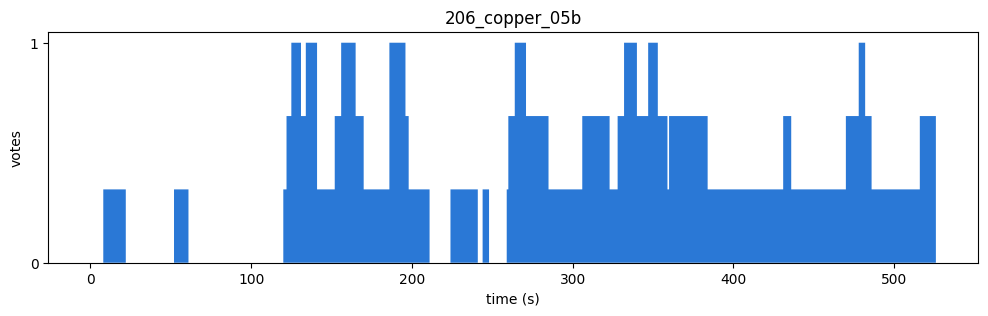

In [13]:
import matplotlib.pyplot as plt
vote_curve, majority_spans, rows = {}, {}, []

labels = load_labels()
print(labels)
edges, votes = importance_votes(labels, weights=WEIGHTS)
n_ann = len(labels)
vote_curve = (edges, votes)
majority_spans = consensus_spans(edges, votes, n_ann / 2 + 1e-9)
rows.append(dict(
    case=case_name,
    annotators=n_ann,
    names="/".join(sorted(l["annotator"] for l in labels)),
    dur_s=edges[-1],
    any_s=float((votes >= 1).sum() * BIN_S),
    majority_s=float((votes > n_ann / 2).sum() * BIN_S),
    unanimous_s=float((votes == n_ann).sum() * BIN_S),
    n_spans=len(majority_spans),
    ))

import matplotlib.pyplot as plt
edges, votes = vote_curve

fig, ax = plt.subplots(figsize=(12, 3))
ax.stairs(votes, edges, fill=True, color="#2a78d6")
ax.set_xlabel("time (s)")
ax.set_ylabel("votes")
ax.set_yticks(range(int(votes.max()) + 1))
ax.set_title(case_name)
plt.show()

saved /workspace/project/writing/Figures/sys_eval/206_copper_05b_edit_overlaps.pdf


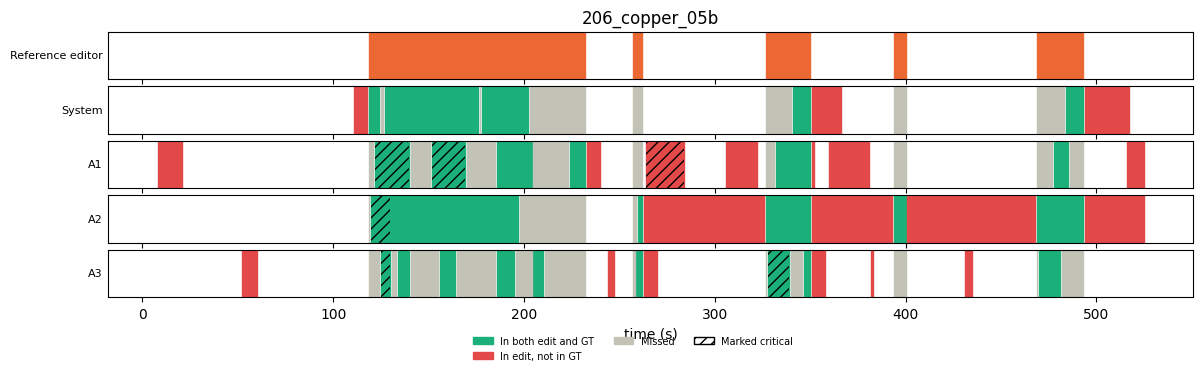

In [14]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from Eval_defs import timeline_agreement
TP_C, FP_C, FN_C, REF_C = "#1baf7a", "#e34948", "#c3c2b7", "#eb6834"


import matplotlib.pyplot as plt
from matplotlib.patches import Patch

tracks = {"ME (GT)": GT_edit, "machine": machine_paper_edit}
for l in load_labels():
    tracks[l["annotator"]] = annotator_beats_to_grid(l, edges)
timeline_agreement(case_name, edges, tracks, GT_edit=GT_edit, fname = f"{asset_name()}_edit_overlaps.pdf" )


In [15]:
decay_s=4
rows = [dict(editor="GT", time_min=70.0,
             **score_paper_vs_GT_edits(GT_edit, GT_edit, decay_s=decay_s))]

rows.append(dict(editor="machine", time_min=np.nan,
                 **score_paper_vs_GT_edits(GT_edit, machine_paper_edit, decay_s=decay_s)))

for l in load_labels():
    rows.append(dict(editor=l["annotator"],
                     time_min=round(l["time_spent_sec"] / 60, 1),
                     **score_paper_vs_GT_edits(GT_edit, annotator_beats_to_grid(l, edges), decay_s=decay_s)))
rand_row, null_stats, density = random_baseline_blocks(GT_edit, machine_paper_edit)
rows.append(rand_row)
rows.append(dict(editor="whole clip", time_min=np.nan,
                 **score_paper_vs_GT_edits(GT_edit, np.ones_like(GT_edit), decay_s=decay_s)))
comp = pd.DataFrame(rows)
comp[["editor", "edit_s" , "soft_f1",
      
      "soft_precision", 
      "soft_recall", 
      "soft_specificity", 
      "iou", "len_ratio", "n_segments", "median_seg_s","time_min" ]].round(3)



,editor,edit_s,soft_f1,soft_precision,soft_recall,soft_specificity,iou,len_ratio,n_segments,median_seg_s,time_min
0,GT,176.0,1.000,1.000,1.000,1.000,1.000,1.000,5.00,24.00,70.0
1,machine,149.0,0.657,0.708,0.612,0.876,0.451,0.847,5.00,26.00,NaN
2,George,186.0,0.558,0.513,0.612,0.741,0.341,1.057,11.00,18.00,35.5
3,Tamara,344.0,0.558,0.429,0.800,0.439,0.358,1.955,2.00,172.00,7.9
4,Vuk,106.0,0.592,0.689,0.518,0.906,0.330,0.602,13.00,9.00,13.3
5,"random (blocks, n=200)",149.0,0.344,0.373,0.319,0.733,0.194,0.847,4.96,26.29,NaN
6,whole clip,526.0,0.533,0.363,1.000,0.043,0.335,2.989,1.00,526.00,NaN


In [16]:
null_stats

,Producer_agent_score,mean,p05,p95,pct
iou,0.451,0.194,0.058,0.360,98.5
soft_f1,0.657,0.344,0.130,0.562,98.5
precision,0.678,0.344,0.120,0.577,98.5
recall,0.574,0.291,0.102,0.489,98.5
specificity,0.863,0.721,0.626,0.820,98.5


saved /workspace/project/writing/Figures/sys_eval/206_copper_05b_edit_overlaps.pdf


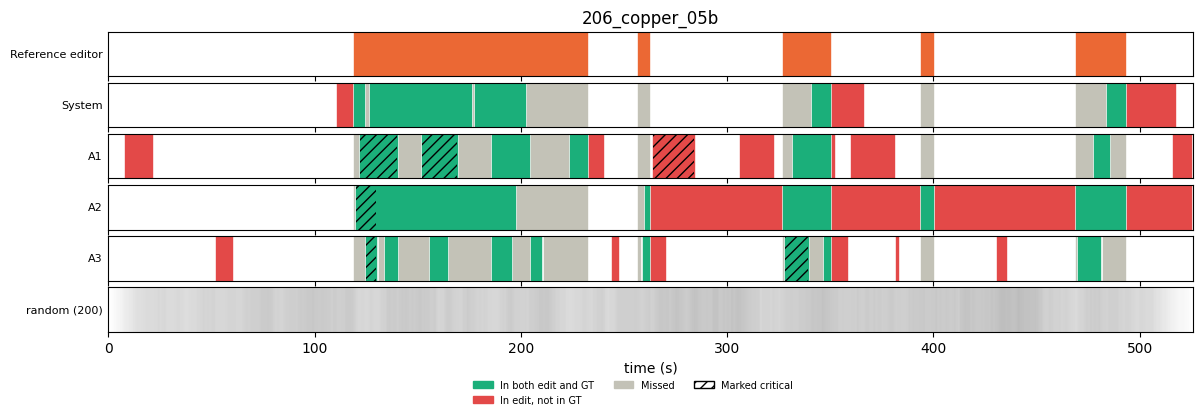

In [17]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from Eval_defs import timeline_agreement
TP_C, FP_C, FN_C, REF_C = "#1baf7a", "#e34948", "#c3c2b7", "#eb6834"


import matplotlib.pyplot as plt
from matplotlib.patches import Patch

tracks = {"ME (GT)": GT_edit, "machine": machine_paper_edit}
for l in load_labels():
    tracks[l["annotator"]] = annotator_beats_to_grid(l, edges)
tracks["random (200)"] = density
timeline_agreement(case_name, edges, tracks, GT_edit=GT_edit,
                   fname=f"{asset_name()}_edit_overlaps.pdf")




In [18]:
cols = ["editor", "time_min", "edit_s", "len_ratio",
        "soft_f1", "soft_precision", "soft_recall", "soft_specificity",
        "iou", "n_segments", "median_seg_s"]

nice = {"editor": "Editor", "time_min": "Time (min)", "edit_s": "Cut (s)",
        "len_ratio": "Len ratio", "soft_f1": "Soft $F_1$",
        "soft_precision": "Soft prec.", "soft_recall": "Soft rec.",
        "soft_specificity": "Soft spec.", "iou": "IoU",
        "n_segments": "Shots", "median_seg_s": "Median shot (s)"}

(comp[cols].rename(columns=nice)
 .to_latex(project_root / "writing" /"Figures" / "sys_eval"/ f"{case_name}_{experiment}_table_comp.tex",
           index=False, escape=False, float_format="%.3f",
           column_format="lrrrrrrrrrr",
           caption=f"Editors scored against the reference cut, {case_name}",
           label="tab:noodles_comp",
           position="htbp"))
